# Complete code for replicating results

In [1]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import torch
from torch import nn
import random

In [2]:
llama_df = pd.read_csv("pcaps/llama.csv", encoding='latin-1')
gemini_df = pd.read_csv("pcaps/gemini.csv", encoding='latin-1')
grok_df = pd.read_csv("pcaps/grok.csv", encoding='latin-1')

with open('src/llama.json', 'r') as f: llama_labels = json.load(f)
with open('src/gemini.json', 'r') as f: gemini_labels = json.load(f)
with open('src/grok.json', 'r') as f: grok_labels = json.load(f)

## basic utility functions

In [3]:
def extract_ip_addresses_from_dns_info(info_str):
    words = info_str.split(' ')
    ips = []
    
    for w in words:
        if len(w.split('.')) == 4:
            ips.append(w)
    return ips

In [4]:
def get_open_website_ips(df, website_name):
    dns_packets = df[df["Protocol"] == "DNS"].iterrows()
    open_router_ips = []
    
    for row in dns_packets:
        info_str = row[1]["Info"]
        if ("Standard query response" in info_str) and (website_name in info_str):
            new_open_router_ips = extract_ip_addresses_from_dns_info(info_str)
            open_router_ips.extend(new_open_router_ips)          
    return list(set(open_router_ips))

## visualize/investigate data

In [5]:
def plot_first_n_api_calls(model_df, n,title=""):

    assert n > 0
    dns_artifcat_times = []

    for i, row in model_df.iterrows():
        if len(dns_artifcat_times) >= n:
            break
        
        info_str = row['Info']
        if ("Standard query response" in info_str) and ('zephaniahdev.com' in info_str):
            dns_artifcat_times.append(row['Time'])

    open_router_ips = get_open_website_ips(model_df, "openrouter.ai")
    first_api_calls_df = model_df[model_df['Time'] < dns_artifcat_times[-1]]
    only_open_router = first_api_calls_df[first_api_calls_df['Source'].isin(open_router_ips) | first_api_calls_df['Destination'].isin(open_router_ips) ]

    # claude helped with some basic plotting here
    # https://claude.ai/share/c4f19cf7-0add-4b23-b071-ee2b05c732aa
    plt.figure(figsize=(13, 6))
    plt.scatter(only_open_router['Time'], only_open_router['Length'])
    for t in dns_artifcat_times:
        plt.axvline(x=t, color='orange', linestyle='-')

    plt.title(title)
    plt.xlabel("time in seconds")
    plt.ylabel("length of packet")
    plt.show()

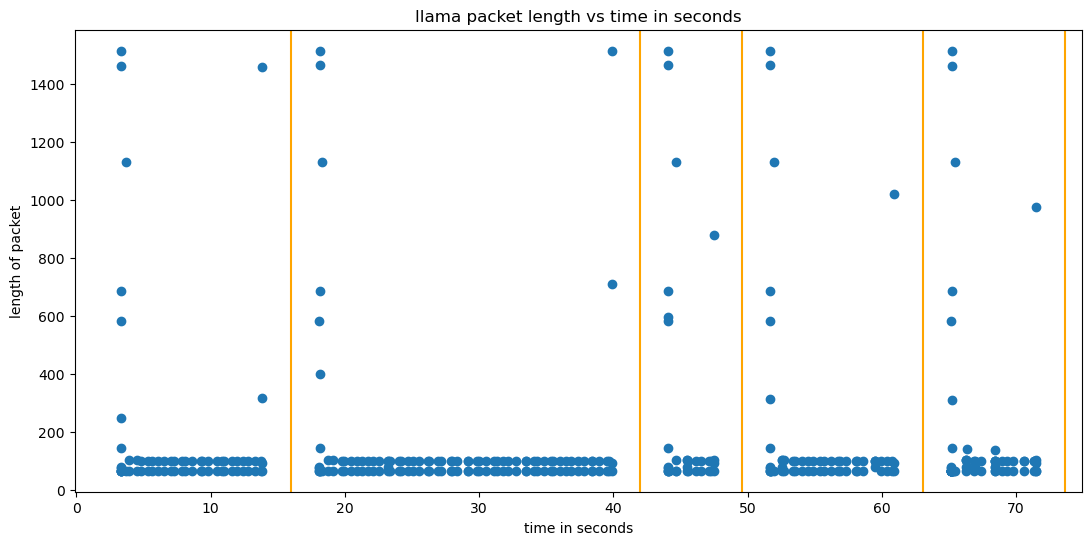

In [6]:
# llama
plot_first_n_api_calls(llama_df, 5, "llama packet length vs time in seconds")

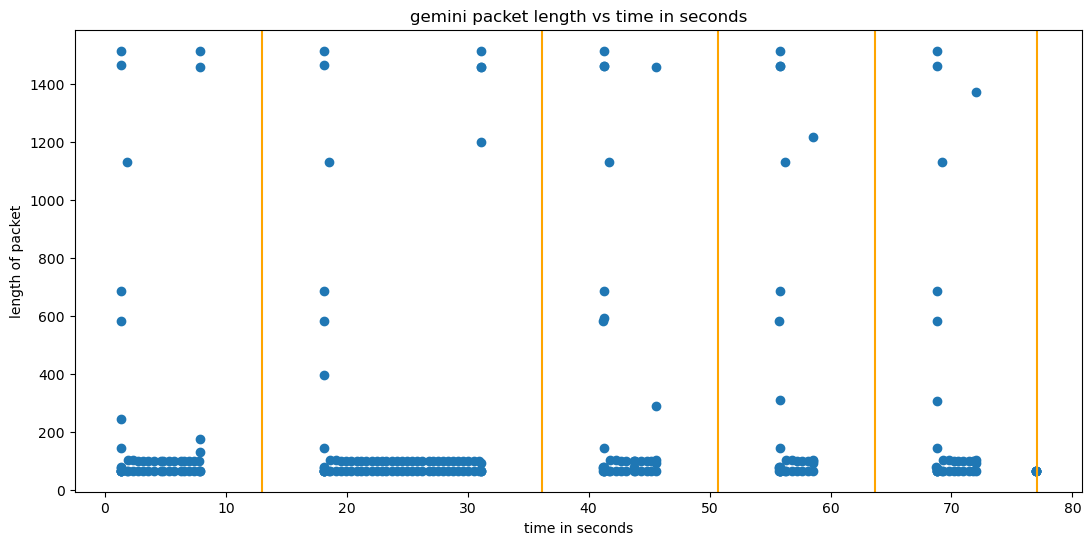

In [7]:
# gemini
plot_first_n_api_calls(gemini_df, 5, "gemini packet length vs time in seconds")

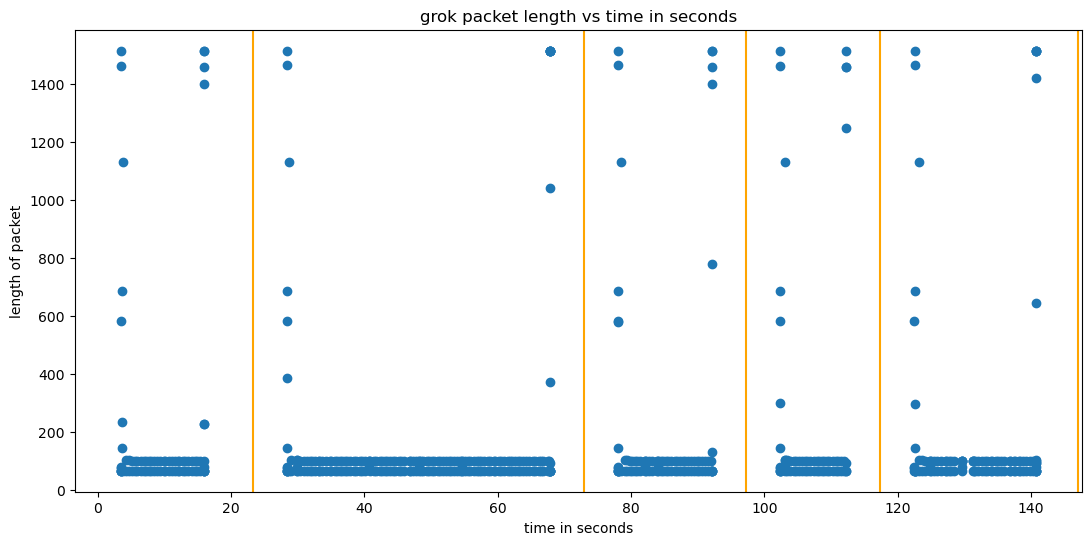

In [8]:
# grok
plot_first_n_api_calls(grok_df, 5, "grok packet length vs time in seconds")

These plots show us all that the data has properly loaded and each api call is separated by a DNS query which we can use to build our training set.

## split data into list of packets for each API call

In [9]:
def split_df_into_api_segments(full_model_df, open_router_ips):
    
    # 2d array where each list corresponds to an api call and the contents of the list are the
    # idxs in the dataframe corresponding to that activity
    idxs = []
    current_segment = []

    for i, row in full_model_df.iterrows():
        info_str = row['Info']
        if ("Standard query response" in info_str) and ('zephaniahdev.com' in info_str):
            idxs.append(current_segment)
            current_segment = []
        else:
            if len(current_segment) == 0:
                if row['Source'] not in open_router_ips and row['Destination'] not in open_router_ips:
                    continue
            current_segment.append(i)

    dfs = []
    for segment in idxs:
        # used claude to know the proper syntax here
        # https://claude.ai/share/28847658-d5bc-4b08-93dd-f71e9240b13f
        dfs.append(full_model_df.iloc[segment].copy())

    non_zero_segmnets = []
    for i, s in enumerate(dfs):
        if len(s) == 0: print("here", i)
        else:
            s_open = s[s['Source'].isin(open_router_ips) | s['Destination'].isin(open_router_ips) ]
            non_zero_segmnets.append(s_open)

    return non_zero_segmnets

In [10]:
open_router_ips = get_open_website_ips(grok_df, "openrouter.ai")
open_router_ips += get_open_website_ips(gemini_df, "openrouter.ai")
open_router_ips += get_open_website_ips(llama_df, "openrouter.ai")
open_router_ips = list(set(open_router_ips))
print(open_router_ips)

grok_segments = split_df_into_api_segments(grok_df, open_router_ips)
gemini_segments = split_df_into_api_segments(gemini_df, open_router_ips)
llama_segments = split_df_into_api_segments(llama_df, open_router_ips)

['104.18.2.115', '104.18.3.115']
here 81


Now we have our dataset in the form of lists of dataframes ONLY contianing the packets involved with each api call to open router. Each dataframe in the list corresponds to a single API call.

## visualize relationship between bytes and tokens

As a sanity check, we know there should be some sort of correlation between the total data in the api flow and the number of tokens eventually delivered. In the graph below we can see that rough relationship which should give us some amount of confidence that the labels we saved correspond to the API traffic we extracted at the previous step.

In [11]:
def plot_tokens_vs_total_bytes(segments, labels, model):
    assert len(segments) == len(labels)

    num_bytes = [sum(s['Length']) for s in segments]
    completion_tokens = [l['completion_tokens'] for l in labels]
    prompt_tokens = [l['prompt_tokens'] for l in labels]

    plt.title(f"{model}: tokens vs bytes in api call flow")
    plt.scatter(num_bytes, completion_tokens, label="completion tokens")
    plt.scatter(num_bytes, prompt_tokens, label="prompt tokens")
    plt.legend()
    plt.show()

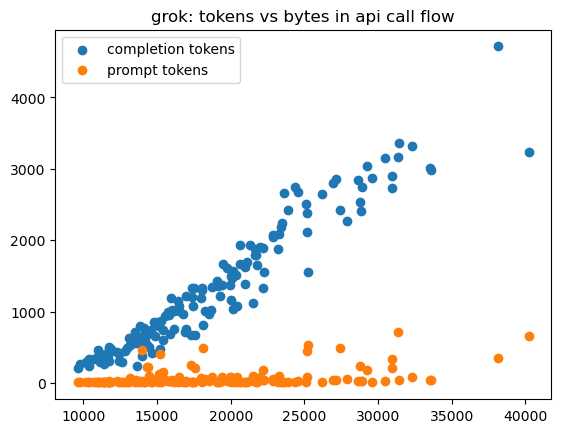

In [12]:
plot_tokens_vs_total_bytes(grok_segments, grok_labels, 'grok')

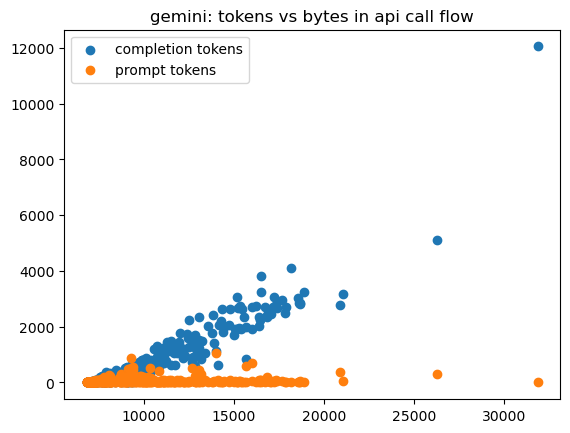

In [13]:
plot_tokens_vs_total_bytes(gemini_segments, gemini_labels, 'gemini')

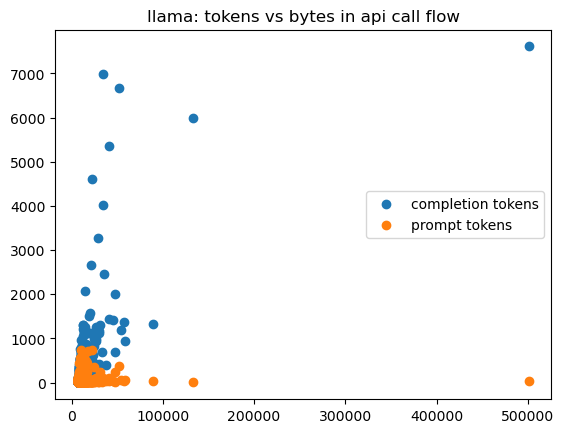

In [14]:
plot_tokens_vs_total_bytes(llama_segments, llama_labels, 'llama')

## motivating issue: where linear models fail 

In [15]:
from sklearn import linear_model

In [16]:
def get_linear_models(segments, labels):
    assert len(segments) == len(labels)

    num_bytes = [sum(s['Length']) for s in segments]
    completion_tokens = [l['completion_tokens'] for l in labels]
    prompt_tokens = [l['prompt_tokens'] for l in labels]

    reg_completion = linear_model.LinearRegression()
    reg_completion.fit(np.array(num_bytes).reshape(-1, 1), completion_tokens)
    m_completion, b_completion = float(reg_completion.coef_[0]), float(reg_completion.intercept_)

    reg_prompt = linear_model.LinearRegression()
    reg_prompt.fit(np.array(num_bytes).reshape(-1, 1), prompt_tokens)
    m_prompt, b_prompt = float(reg_prompt.coef_[0]), float(reg_prompt.intercept_)
    
    return m_completion, b_completion, m_prompt, b_prompt

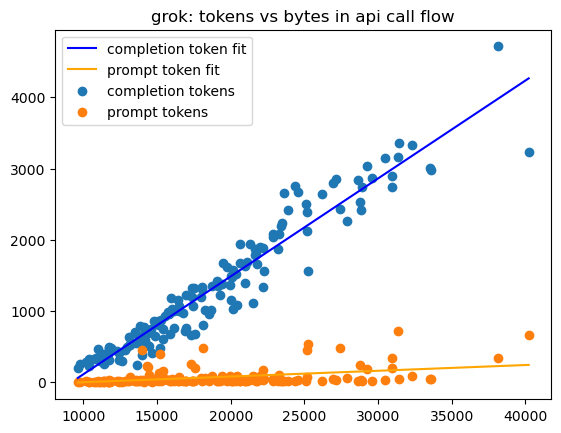

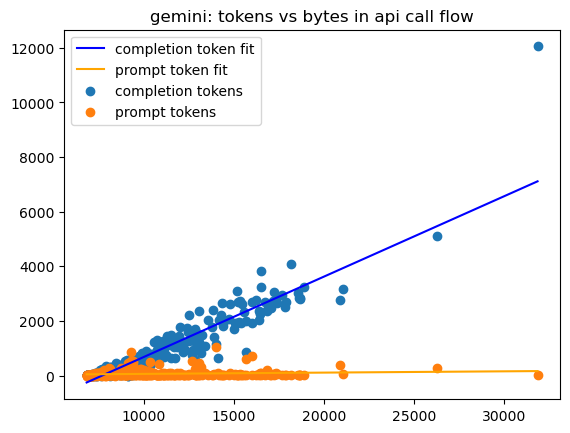

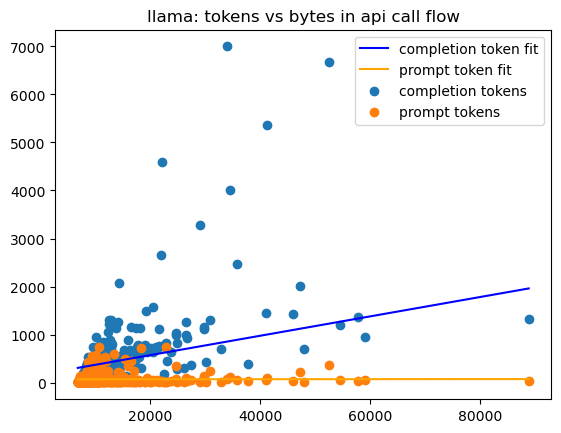

In [17]:
def plot_regression(segments, labels, model, m_completion, b_completion, m_prompt, b_prompt):
    # remove outliers
    segments_new = []
    labels_new = []
    for s,l in zip(segments, labels):
        if not sum(s['Length']) > 100_000:
            segments_new.append(s)
            labels_new.append(l)
    segments, labels = segments_new, labels_new
    
    max_bytes = max([sum(s['Length']) for s in segments])
    min_bytes = min([sum(s['Length']) for s in segments])

    reg_completion_x = np.linspace(min_bytes,max_bytes, max_bytes - min_bytes + 1)
    reg_completion_y = reg_completion_x * m_completion + b_completion

    reg_prompt_x = np.linspace(min_bytes,max_bytes, max_bytes - min_bytes + 1)
    reg_prompt_y = reg_prompt_x * m_prompt + b_prompt
    
    plt.plot(reg_completion_x, reg_completion_y, color='blue', label="completion token fit")
    plt.plot(reg_prompt_x, reg_prompt_y, color='orange', label="prompt token fit")
    
    plot_tokens_vs_total_bytes(segments, labels, model)

m_c, b_c, m_p, b_p = get_linear_models(grok_segments, grok_labels)
plot_regression(grok_segments, grok_labels, 'grok', m_c, b_c, m_p, b_p)

m_c, b_c, m_p, b_p = get_linear_models(gemini_segments, gemini_labels)
plot_regression(gemini_segments, gemini_labels, 'gemini', m_c, b_c, m_p, b_p)

m_c, b_c, m_p, b_p = get_linear_models(llama_segments, llama_labels)
plot_regression(llama_segments, llama_labels, 'llama', m_c, b_c, m_p, b_p)

The plots above show that we can fit a simple linear model to our data to predict the number of completion tokens in an API call (based only on the number of bytes in the API call). Unfortunatly, this only holds if we are calling the same model. In the graph below, we can see that it is difficult to fit a line if we put all the grok, gemini, and llama data on the same graph.

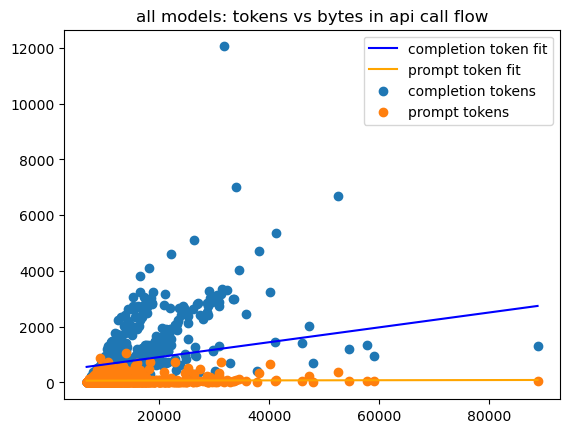

In [18]:
every_api_call = grok_segments + gemini_segments + llama_segments
every_label = grok_labels + gemini_labels + llama_labels

m_c, b_c, m_p, b_p = get_linear_models(every_api_call, every_label)
plot_regression(every_api_call, every_label, 'all models', m_c, b_c, m_p, b_p)

## design data representation for model

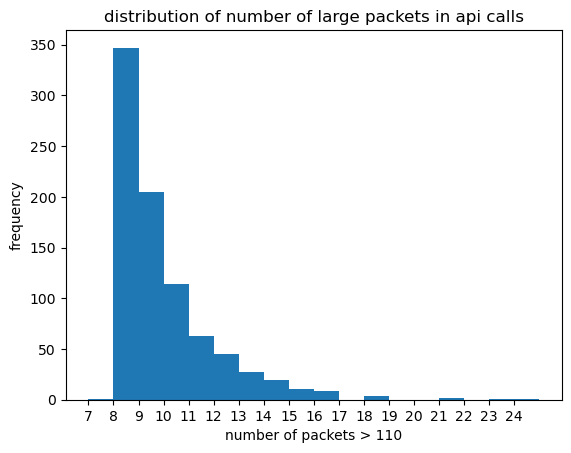

In [19]:
all_segments = [grok_segments, gemini_segments, llama_segments]

def plot_larger_packets_distribution(threshold=110):
    num_larger_packets = []
    
    for api_calls in all_segments:
        for api_call in api_calls:
            num_larger_packets.append(sum(api_call['Length'] >  threshold))

    # I used claude here to make this graph look nicer
    # https://claude.ai/share/af18cc55-c86f-4b1c-8ff1-181511e5e243
    plt.title(f'distribution of number of large packets in api calls')

    min_val = min(num_larger_packets)
    max_val = max(num_larger_packets)
    bins = range(min_val, max_val + 2) 
    
    plt.hist(num_larger_packets, bins=bins)
    plt.xlabel(f'number of packets > {threshold}')
    plt.ylabel('frequency')
    plt.xticks(range(min_val, max_val + 1))

plot_larger_packets_distribution()

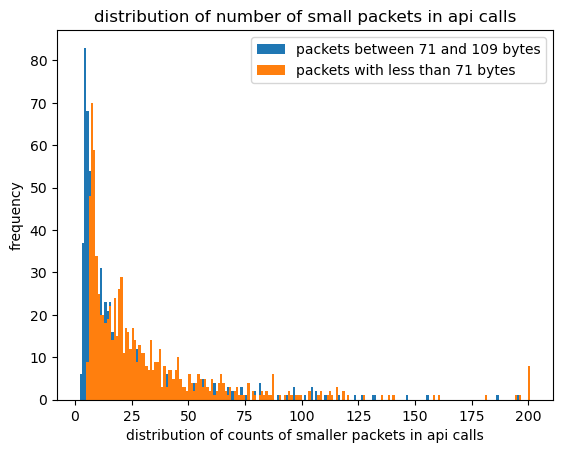

In [20]:
def plot_smaller_packets_distribution():
    small_threshold = 110
    smaller_threshold = 70
    
    num_small_packets = []
    num_smaller_packets = []
    
    
    for api_calls in all_segments:
        for api_call in api_calls:
            num_small = sum((api_call['Length'] <  small_threshold) & (api_call['Length'] >  smaller_threshold))
            num_small_packets.append(min(num_small, 200))
            num_smaller = sum(api_call['Length'] <=  smaller_threshold)
            num_smaller_packets.append(min(num_smaller, 200))

    # I used claude here to make this graph look nicer
    # https://claude.ai/share/af18cc55-c86f-4b1c-8ff1-181511e5e243
    plt.title(f'distribution of number of small packets in api calls')

    min_val = min(min(num_small_packets), min(num_smaller_packets))
    max_val = max(min(num_small_packets), max(num_smaller_packets))
    bins = range(min_val, max_val + 2) 
    
    plt.hist(num_small_packets, bins=bins, label='packets between 71 and 109 bytes')
    plt.hist(num_smaller_packets, bins=bins, label='packets with less than 71 bytes')
    plt.xlabel(f'distribution of counts of smaller packets in api calls')
    plt.ylabel('frequency')
    plt.legend()

plot_smaller_packets_distribution()

**My interpretation of the two graphs above:** In the data we see lots of little packets in between when the api call is made and when the response is received. However, there are very few packets that are larger than 100 bytes even though there may be hundreds of packets assoicated with the api call. 

I believe that there is meaningful signal in the smaller packets, but because they are highly repetitive, I don't think we need to represent them in high resolution. In in the final data model I choose, I only represent the count of the two buckets on packets in the graph above for each API call.

Note that if there are more than 200 of a category of packets, I turn the count into 200 to account for the long tail of outliers. When building the data model in the section below I do the same.

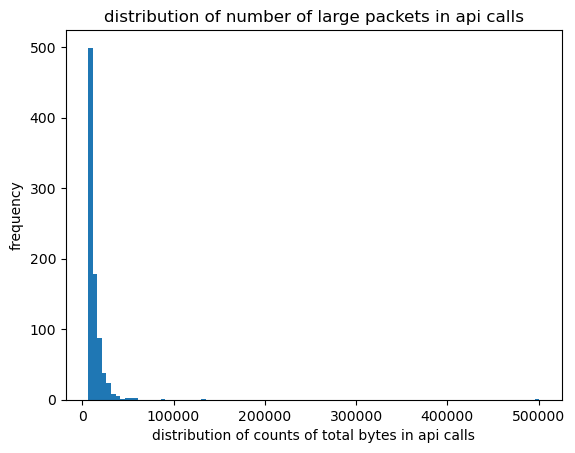

In [21]:
def plot_distribution_total_bytes():
    x = []
    for api_calls in all_segments:
        for api_call in api_calls:
            x.append(sum(api_call['Length']))

    plt.title(f'distribution of number of large packets in api calls')
    
    plt.hist(x,bins=100)
    plt.xlabel(f'distribution of counts of total bytes in api calls')
    plt.ylabel('frequency')
    plt.show()

plot_distribution_total_bytes()

We can also see that there are very api calls with more than 50,000 larger packets. Therefore, I set `MAX_LARGER_BYTES_API_FLOW` to 50,000 in the data model below so that the model doesn't get too confused by the long tail of outliers. 

# building the training set

In this section, I build the data model. For each API call, I store:

1. the number of packets between 71 and 109 bytes
2. the number of packets between 0 and 70 bytes
3. total lenght of larger packets (>109 bytes) in the api call
4. total time for the api call
5. the time and length of the first 20 packets > 109 bytes

In [22]:
max(grok_df['Length']) # packet sizes shouldn't exceed 2000 bytes very often so I set MAX_PACKET_SIZE = 2_000 below

1514

In [23]:
MAX_NUM_SMALL = 200
MAX_NUM_SMALLER = 200
MAX_PACKET_SIZE = 2_000
MAX_LARGER_BYTES_API_FLOW = 50_000
MAX_LARGER_PACKETS = 20
MAX_TIME = 60

def process_api_df_into_tensor(api_call):
    rv = []

    small_threshold = 110
    smaller_threshold = 70

    # num small packets
    num_small = sum((api_call['Length'] <  small_threshold) & (api_call['Length'] >  smaller_threshold))
    rv.append(float(min(num_small, 200)))

    # num smaller packets
    num_smaller = sum(api_call['Length'] <=  smaller_threshold)
    rv.append(float(min(num_smaller, 200)))

    # total_length of larger packets
    total_len_larger = sum(api_call[api_call['Length'] >= small_threshold]['Length'])
    rv.append(float(min(total_len_larger, MAX_LARGER_BYTES_API_FLOW)))
    
    # total time
    total_time = api_call.iloc[-1]['Time']  - api_call.iloc[0]['Time']
    # print(total_time)
    rv.append(float(min(total_time, MAX_TIME)))

    larger_packet_data = [0] * (MAX_LARGER_PACKETS * 2 -1)
    min_time = float(min(api_call['Time']))

    idx = 0
    for _, row in api_call.iterrows():
        if idx >= len(larger_packet_data):
            break
        
        if row["Length"] < small_threshold:
            continue
        try:
            
            if row["Length"] == 0:
                print('here', row)

            # time will always be zero for first packet so we don't need to record it
            if idx == 0:
                larger_packet_data[0] = float(min(row["Length"], MAX_PACKET_SIZE))
                idx += 1
            else:
                larger_packet_data[idx] = float(min(row["Length"], MAX_PACKET_SIZE))
                idx += 1
                larger_packet_data[idx] = float(min(row["Time"] - min_time, MAX_TIME))
                idx += 1
        except:
            print(idx)
            assert False
    
    return torch.tensor(rv + larger_packet_data)

In [24]:
grok_data = torch.zeros(len(grok_segments), 43)

for i, s in enumerate(grok_segments):
    grok_data[i] = process_api_df_into_tensor(s)

gemini_data = torch.zeros(len(gemini_segments), 43)

for i, s in enumerate(gemini_segments):
    gemini_data[i] = process_api_df_into_tensor(s)

llama_data = torch.zeros(len(llama_segments), 43)

for i, s in enumerate(llama_segments):
    llama_data[i] = process_api_df_into_tensor(s)

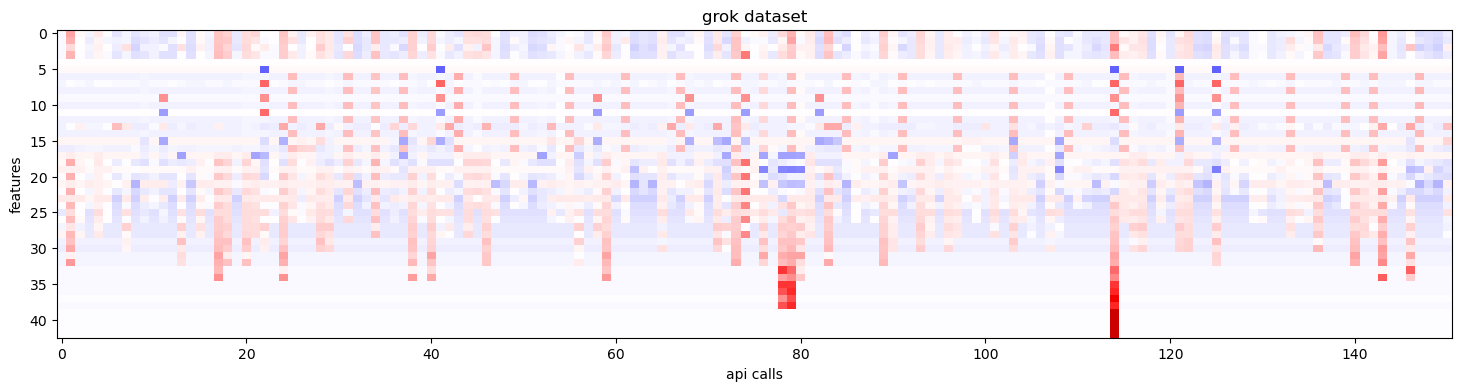

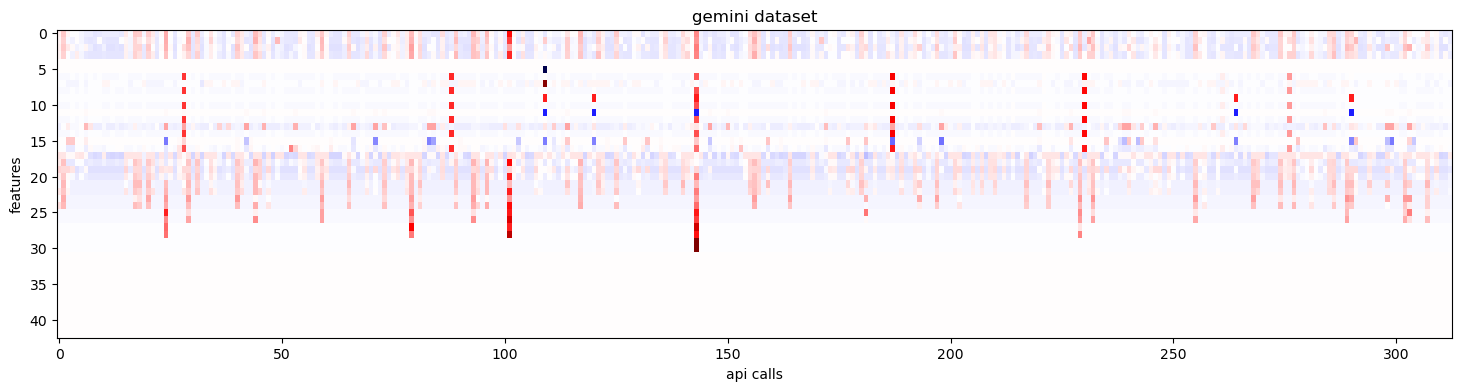

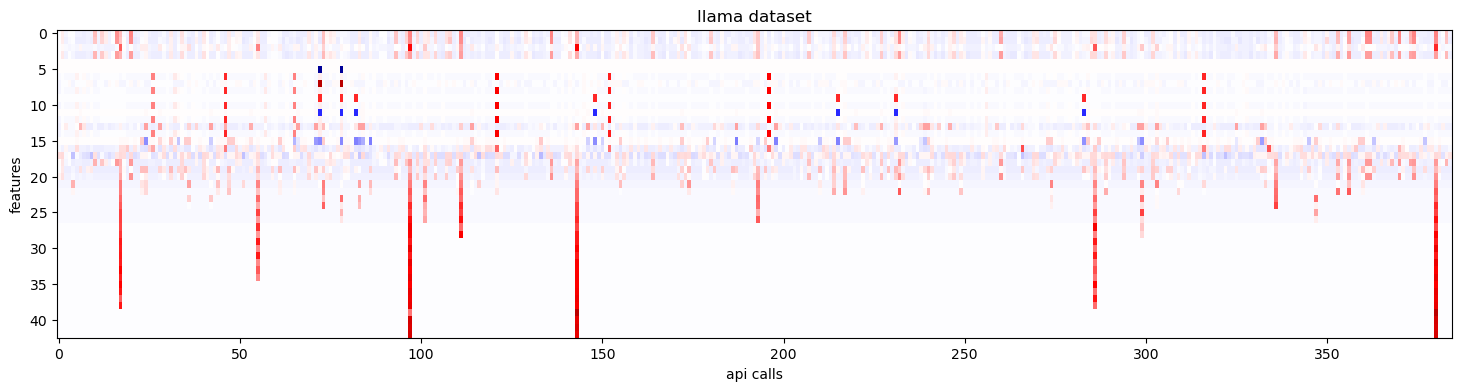

In [25]:
grok_normalized = (grok_data - grok_data.mean(dim=0))  / (grok_data.std(dim=0) + 1e-5)
gemini_normalized = (gemini_data - gemini_data.mean(dim=0))  / (gemini_data.std(dim=0) + 1e-5)
llama_normalized = (llama_data - llama_data.mean(dim=0))  / (llama_data.std(dim=0) + 1e-5)

# Claude helped write the below plotting code
# https://claude.ai/share/630f893d-77f3-422e-937c-52769e9f3b90

# Find global min/max across all datasets
vmin = min(grok_normalized.min(), gemini_normalized.min(), llama_normalized.min())
vmax = max(grok_normalized.max(), gemini_normalized.max(), llama_normalized.max())

plt.figure(figsize=(18, 4))
plt.title('grok dataset')
plt.imshow(grok_normalized.T, aspect='auto', cmap="seismic", vmin=vmin, vmax=vmax)
plt.ylabel('features')
plt.xlabel('api calls')

plt.figure(figsize=(18, 4))
plt.title('gemini dataset')
plt.imshow(gemini_normalized.T, aspect='auto', cmap="seismic", vmin=vmin, vmax=vmax)
plt.ylabel('features')
plt.xlabel('api calls')

plt.figure(figsize=(18, 4))
plt.title('llama dataset')
plt.imshow(llama_normalized.T, aspect='auto', cmap="seismic", vmin=vmin, vmax=vmax)
plt.ylabel('features')
plt.xlabel('api calls')

plt.show()

In [26]:
def get_labels(list_of_labels_lists):
    completion_tokens = []
    prompt_tokens = []
    costs = []
    
    for labels_list in list_of_labels_lists:
        for label in labels_list:
            completion_tokens.append(label["completion_tokens"])
            prompt_tokens.append(label["prompt_tokens"])
            costs.append(label["cost"])

    return torch.tensor(completion_tokens), torch.tensor(prompt_tokens), torch.tensor(costs)

train_x = torch.concat((grok_data, gemini_data, llama_data))
train_mean = train_x.mean(dim=0)
train_std = train_x.std(dim=0) + 1e-5
train_x = (train_x - train_mean)  / (train_std)
completion_y, prompt_y, costs_y = get_labels([grok_labels, gemini_labels, llama_labels])

In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

def train_linear(train, labels):
    reg = linear_model.LinearRegression()
    reg.fit(train, labels)
    train_predict = reg.predict(train)
    return reg

def train_ridge(train, labels):
    reg = linear_model.Ridge(alpha=.5)
    reg.fit(train, labels)
    train_predict = reg.predict(train)
    return reg

class regression_mlp(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(43, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

def trian_mlp(hidden_dim, datax, datay, num_batchs=849 * 100, lr=1e-3):
    model = regression_mlp(hidden_dim)
    batch_size = 16
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for b in range(num_batchs):
        batch = torch.zeros(16, 43)
        batchy = torch.zeros(16,)

        for i in range(batch_size):
            random_idx = random.randint(0, len(datax) - 1)
            y = datay[random_idx]

            batch[i] = datax[random_idx]
            batchy[i] = y

        out = model(batch)
        loss = sum((out.view(batch_size,) - batchy)**2) / len(batchy)
        
        loss.backward()
        optimizer.step()
        model.zero_grad()

    return model

In [28]:
# should take ~2 minutes to run 

completion_models = dict()

completion_models['vanilla_linear_completion'] = train_linear(train_x, completion_y)
completion_models['ridge_linear_completion'] = train_ridge(train_x, completion_y)
completion_models['mlp_256_hidden_completion'] = trian_mlp(256, train_x, completion_y)
completion_models['mlp_128_hidden_completion'] = trian_mlp(128, train_x, completion_y)
completion_models['mlp_32_hidden_completion'] = trian_mlp(32, train_x, completion_y)

In [29]:
# should take ~2 minutes to run 

prompt_models = dict()

prompt_models['vanilla_linear_prompt'] = train_linear(train_x, prompt_y)
prompt_models['ridge_linear_prompt'] = train_ridge(train_x, prompt_y)
prompt_models['mlp_256_hidden_prompt'] = trian_mlp(256, train_x, prompt_y)
prompt_models['mlp_128_hidden_prompt'] = trian_mlp(128, train_x, prompt_y)
prompt_models['mlp_32_hidden_prompt'] = trian_mlp(32, train_x, prompt_y)

In [30]:
# should take ~2 minutes to run 

cost_models = dict()

cost_models['vanilla_linear_cost'] = train_linear(train_x, costs_y)
cost_models['ridge_linear_cost'] = train_ridge(train_x, costs_y)
cost_models['mlp_256_hidden_cost'] = trian_mlp(256, train_x, costs_y)
cost_models['mlp_128_hidden_cost'] = trian_mlp(128, train_x, costs_y)
cost_models['mlp_32_hidden_cost'] = trian_mlp(32, train_x, costs_y)

In [31]:
def evalute_models(models, train, y):

    for k, model in models.items():
        if 'linear' in k:
            out = model.predict(train)
            mse = mean_squared_error(out, y)
            mae = mean_absolute_error(out, y)

            print(f"[{k}]\t:\t mse = {mse:.3}, mae = {mae:.3}")
        else:
            with torch.no_grad():
                out = model(train)
                mse = sum((out.view(-1,) - y)**2) / len(y)
                mae = sum(abs(out.view(-1,) - y)) / len(y)
            print(f"[{k}]\t:\t mse = {mse:.3}, mae = {mae:.3}")

In [32]:
evalute_models(completion_models, train_x, completion_y)

[vanilla_linear_completion]	:	 mse = 2.64e+05, mae = 2.71e+02
[ridge_linear_completion]	:	 mse = 2.66e+05, mae = 2.69e+02
[mlp_256_hidden_completion]	:	 mse = 3.52e+03, mae = 34.0
[mlp_128_hidden_completion]	:	 mse = 9.37e+03, mae = 55.4
[mlp_32_hidden_completion]	:	 mse = 2.21e+04, mae = 86.9


In [33]:
evalute_models(prompt_models, train_x, prompt_y)

[vanilla_linear_prompt]	:	 mse = 2.27e+03, mae = 22.5
[ridge_linear_prompt]	:	 mse = 2.28e+03, mae = 22.6
[mlp_256_hidden_prompt]	:	 mse = 36.5, mae = 3.52
[mlp_128_hidden_prompt]	:	 mse = 21.7, mae = 3.22
[mlp_32_hidden_prompt]	:	 mse = 1.35e+02, mae = 5.97


In [34]:
evalute_models(cost_models, train_x, costs_y)

[vanilla_linear_cost]	:	 mse = 4.78e-08, mae = 0.000121
[ridge_linear_cost]	:	 mse = 4.82e-08, mae = 0.000121
[mlp_256_hidden_cost]	:	 mse = 1.82e-07, mae = 0.000267
[mlp_128_hidden_cost]	:	 mse = 3.73e-08, mae = 9.86e-05
[mlp_32_hidden_cost]	:	 mse = 9.16e-09, mae = 5.12e-05


tensor(12047)


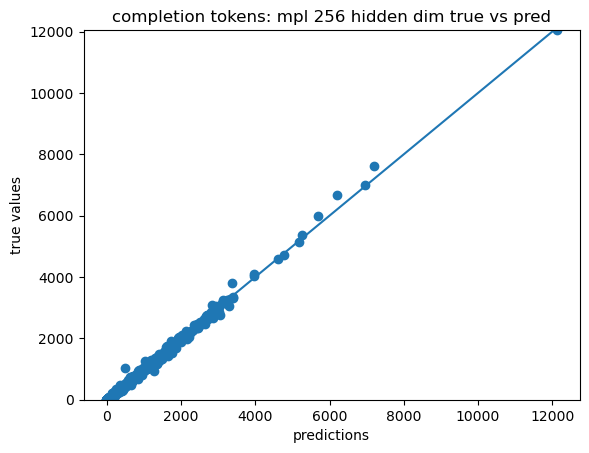

tensor(1047)


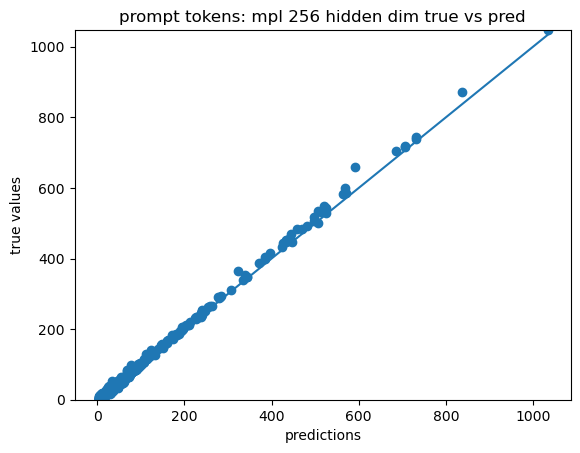

tensor(0.0048)


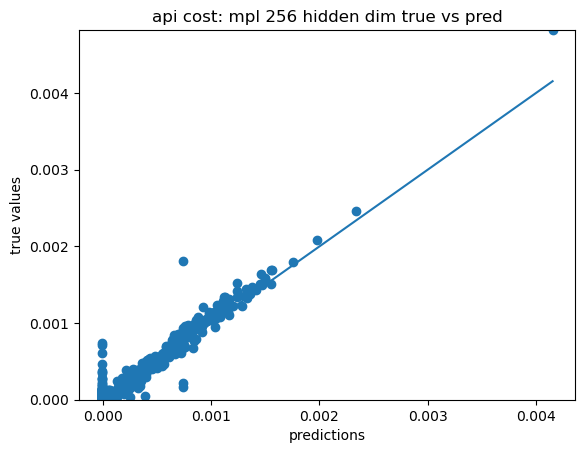

In [35]:
def plot_true_vs_pred(model, is_linear, train, ys, title):
    preds = None
    
    if is_linear:
        preds = model.predict(train)
    else:
        with torch.no_grad():
            preds = model(train)

    y_equals_x = torch.linspace(0, max(preds).item(), 100)
    # print(y_equals_x)
    plt.plot(y_equals_x, y_equals_x)

    plt.scatter(preds, ys)
    plt.title(title)
    plt.xlabel("predictions")
    plt.ylabel("true values")
    print(max(ys))
    # if 'mlp_256_hidden_cost'
    plt.ylim(0 , max(ys))
    plt.show()

plot_true_vs_pred(completion_models['mlp_256_hidden_completion'], False, train_x, completion_y, title="completion tokens: mpl 256 hidden dim true vs pred")
plot_true_vs_pred(prompt_models['mlp_256_hidden_prompt'], False, train_x, prompt_y, title="prompt tokens: mpl 256 hidden dim true vs pred")
plot_true_vs_pred(cost_models['mlp_32_hidden_cost'], False, train_x, costs_y, title="api cost: mpl 256 hidden dim true vs pred")

In the plots above I show the true values vs the predictions on the test set for the best models in each category. To make things easier to look at, I also plot the line y=x. If the model perfectly fit the training set, each dot would land on that line.

## Test set

The test set contains 50 API calls where each call is randomly sampled from a model on a prompt which was not used to train the model. 

In [36]:
test_df = pd.read_csv("pcaps/test.csv", encoding='latin-1')

with open('src/test.json', 'r') as f: test_labels = json.load(f)
test_segments = split_df_into_api_segments(test_df, open_router_ips)

test_data = torch.zeros(len(test_segments), 43)
 
for i, s in enumerate(test_segments):
    test_data[i] = process_api_df_into_tensor(s)

test_data = (test_data - train_mean)/ train_std

t_completion_y, t_prompt_y, t_costs_y = get_labels([test_labels])

Text(0.5, 0, 'api calls')

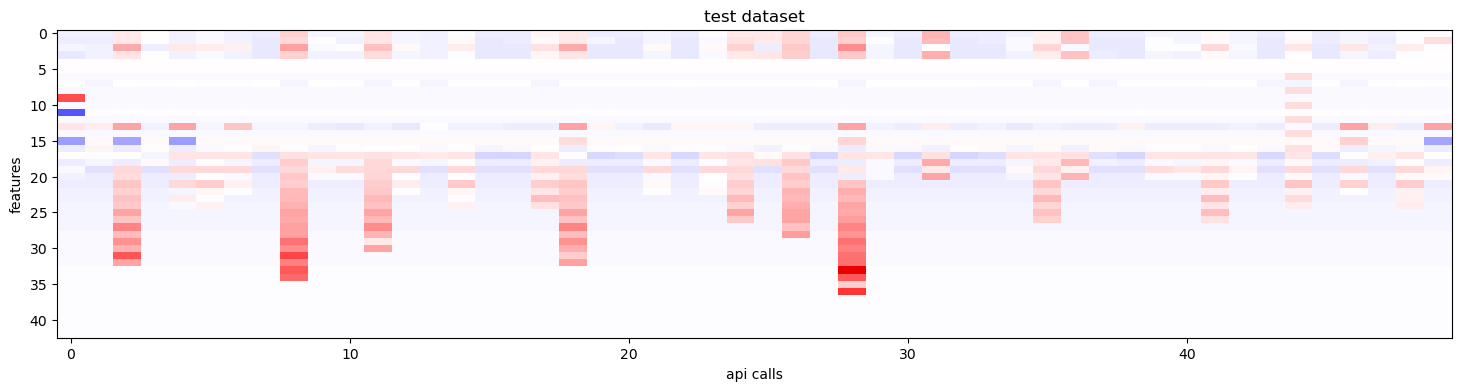

In [37]:
plt.figure(figsize=(18, 4))
plt.title('test dataset')
plt.imshow(test_data.T, aspect='auto', cmap="seismic", vmin=vmin, vmax=vmax)
plt.ylabel('features')
plt.xlabel('api calls')

In [38]:
evalute_models(completion_models, test_data, t_completion_y)

evalute_models(prompt_models, test_data, t_prompt_y)

evalute_models(cost_models, test_data, t_costs_y)

[vanilla_linear_completion]	:	 mse = 2.07e+05, mae = 3.29e+02
[ridge_linear_completion]	:	 mse = 1.78e+05, mae = 3.03e+02
[mlp_256_hidden_completion]	:	 mse = 2.31e+05, mae = 2.48e+02
[mlp_128_hidden_completion]	:	 mse = 3.18e+05, mae = 2.57e+02
[mlp_32_hidden_completion]	:	 mse = 2.52e+05, mae = 2.64e+02
[vanilla_linear_prompt]	:	 mse = 2.19e+03, mae = 27.7
[ridge_linear_prompt]	:	 mse = 3.35e+03, mae = 29.6
[mlp_256_hidden_prompt]	:	 mse = 9.22e+03, mae = 26.5
[mlp_128_hidden_prompt]	:	 mse = 1.75e+04, mae = 36.5
[mlp_32_hidden_prompt]	:	 mse = 9.17e+03, mae = 26.4
[vanilla_linear_cost]	:	 mse = 7.99e-08, mae = 0.000159
[ridge_linear_cost]	:	 mse = 7.53e-08, mae = 0.000155
[mlp_256_hidden_cost]	:	 mse = 2.46e-07, mae = 0.000328
[mlp_128_hidden_cost]	:	 mse = 3.01e-08, mae = 0.000118
[mlp_32_hidden_cost]	:	 mse = 5.86e-08, mae = 0.000135


These evalution statistics are much worse than the training set but they are still pretty solid. In the plots below, we can see that there is a very strong correlation between the predicted and true values for each of the categories we are interested in.

tensor(3219)


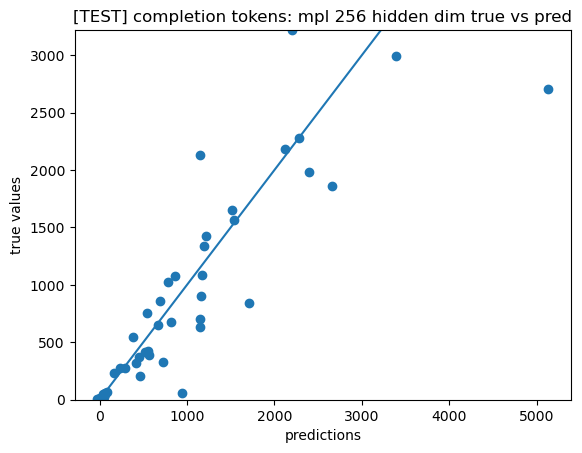

tensor(906)


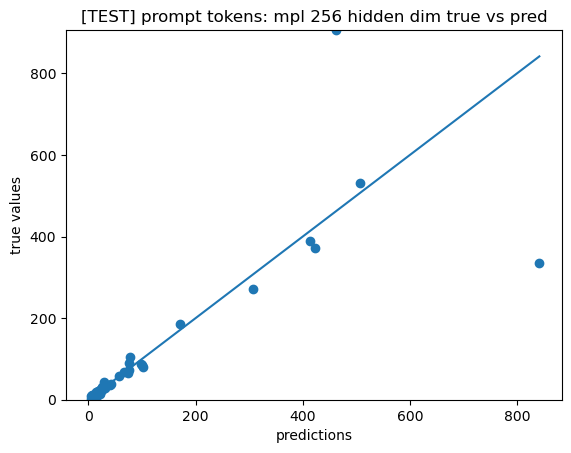

tensor(0.0019)


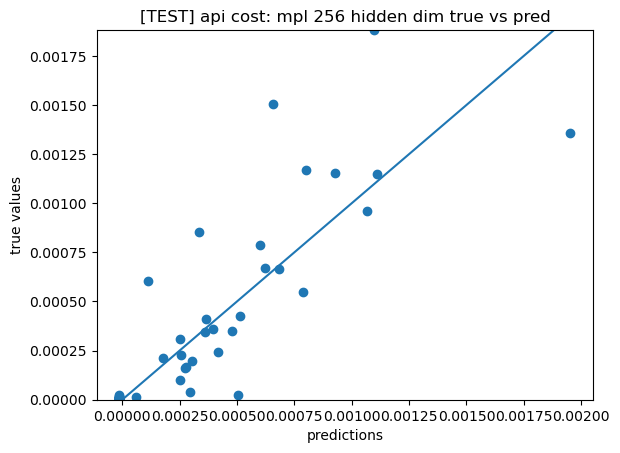

In [39]:
plot_true_vs_pred(completion_models['mlp_256_hidden_completion'], False, test_data, t_completion_y, title="[TEST] completion tokens: mpl 256 hidden dim true vs pred")
plot_true_vs_pred(prompt_models['mlp_256_hidden_prompt'], False, test_data, t_prompt_y, title="[TEST] prompt tokens: mpl 256 hidden dim true vs pred")
plot_true_vs_pred(cost_models['mlp_32_hidden_cost'], False, test_data, t_costs_y, title="[TEST] api cost: mpl 256 hidden dim true vs pred")